In [35]:
import os
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()
DATA_PATH = os.getenv('DATA_PATH')
IMAGE_PATH = os.getenv('IMAGE_PATH')

train_df = os.path.join(DATA_PATH, 'train.json')
val_df = os.path.join(DATA_PATH, 'val.json')

with open(train_df, 'r', encoding='utf-8') as f:
    train_data = json.load(f)

with open(val_df, 'r', encoding='utf-8') as f:
    val_data = json.load(f)

평가 불가 위험군 (500개 초과): 0건


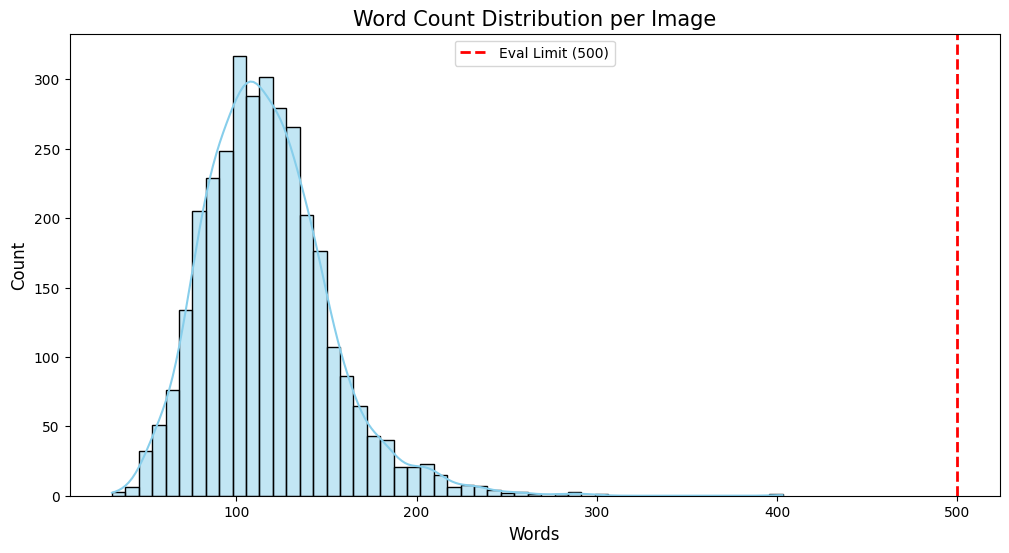

총 이미지 수: 3272


,image_name,word_count
0,drp.en_ko.in_house.selectstar_000003.jpg,89
1,drp.en_ko.in_house.selectstar_000005.jpg,99
2,drp.en_ko.in_house.selectstar_000006.jpg,57
3,drp.en_ko.in_house.selectstar_000008.jpg,162
4,drp.en_ko.in_house.selectstar_000009.jpg,142


In [36]:
# 이미지별 단어 개수 데이터프레임화 (train)
images = train_data.get('images', {})

df = pd.DataFrame([
    {'image_name': name, 'word_count': len(content.get('words', {}))}
    for name, content in images.items()
])

# 500개 넘으면 평가 불가! 위험군 추출
danger_zone = df[df['word_count'] > 500].sort_values(by='word_count', ascending=False)

print(f"평가 불가 위험군 (500개 초과): {len(danger_zone)}건")
if not danger_zone.empty:
    display(danger_zone)

plt.figure(figsize=(12, 6))
sns.histplot(df['word_count'], kde=True, color='skyblue', bins=50)

# 평가 제한선 그리기
plt.axvline(500, color='red', linestyle='--', linewidth=2, label='Eval Limit (500)')

plt.title('Word Count Distribution per Image', fontsize=15)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.show()

print(f"총 이미지 수: {len(df)}")
df.head()

In [37]:
# 실제 이미지 파일과 JSON 목록 일치 여부 확인 (train)
train_dir = os.path.join(IMAGE_PATH, 'train')
json_files = set(train_data.get('images', {}).keys())

valid_extensions = ('.jpg', '.jpeg', '.png', '.JPG', '.PNG')
dir_files = set([f for f in os.listdir(train_dir) if f.endswith(valid_extensions)])

print(f"JSON 내 이미지 수: {len(json_files)}")
print(f"실제 디렉토리 내 이미지 수: {len(dir_files)}")

# JSON에는 정의되어 있으나, 실제 디렉토리에 파일이 없는 경우
missing_in_dir = json_files - dir_files

# 디렉토리에는 파일이 있으나, JSON에는 정의되어 있지 않은 경우
missing_in_json = dir_files - json_files

print(f"\n--- [체크 결과] ---")

if not missing_in_dir and not missing_in_json:
    print("✅ 모든 파일이 완벽하게 일치합니다!")
else:
    if missing_in_dir:
        print(f"\n❌ JSON에만 있고 디렉토리에는 없는 파일 ({len(missing_in_dir)}건):")
        print(list(missing_in_dir)[:10], "...등" if len(missing_in_dir) > 10 else "")

    if missing_in_json:
        print(f"\n❌ 디렉토리에만 있고 JSON에는 없는 파일 ({len(missing_in_json)}건):")
        print(list(missing_in_json)[:10], "...등" if len(missing_in_json) > 10 else "")

JSON 내 이미지 수: 3272
실제 디렉토리 내 이미지 수: 3272

--- [체크 결과] ---
✅ 모든 파일이 완벽하게 일치합니다!


평가 불가 위험군 (500개 초과): 0건


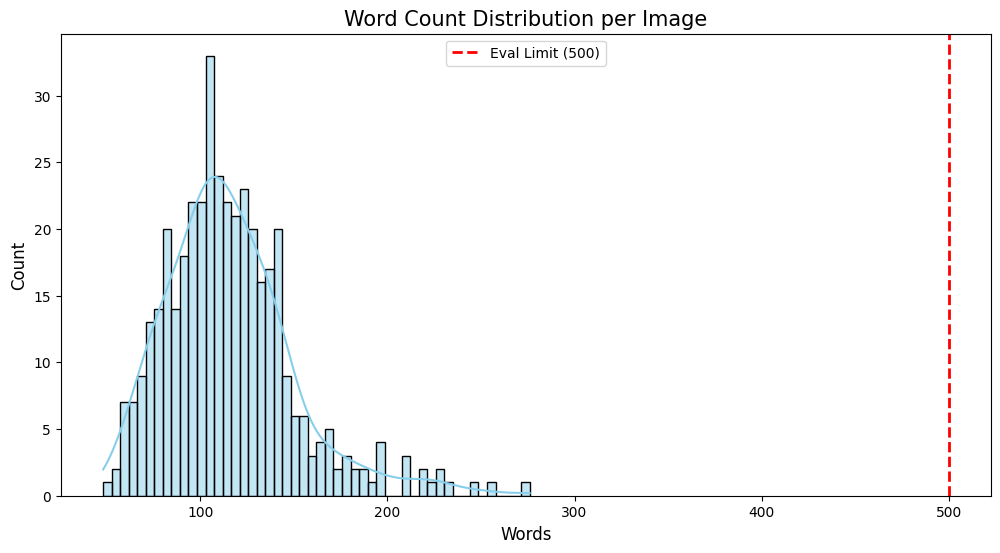

총 이미지 수: 404


,image_name,word_count
0,drp.en_ko.in_house.selectstar_000007.jpg,76
1,drp.en_ko.in_house.selectstar_000030.jpg,127
2,drp.en_ko.in_house.selectstar_000032.jpg,155
3,drp.en_ko.in_house.selectstar_000046.jpg,104
4,drp.en_ko.in_house.selectstar_000056.jpg,196


In [38]:
# 이미지별 단어 개수 데이터프레임화 (valid)
images = val_data.get('images', {})

df = pd.DataFrame([
    {'image_name': name, 'word_count': len(content.get('words', {}))}
    for name, content in images.items()
])

# 500개 넘으면 평가 불가! 위험군 추출
danger_zone = df[df['word_count'] > 500].sort_values(by='word_count', ascending=False)

print(f"평가 불가 위험군 (500개 초과): {len(danger_zone)}건")
if not danger_zone.empty:
    display(danger_zone)

plt.figure(figsize=(12, 6))
sns.histplot(df['word_count'], kde=True, color='skyblue', bins=50)

# 평가 제한선 그리기
plt.axvline(500, color='red', linestyle='--', linewidth=2, label='Eval Limit (500)')

plt.title('Word Count Distribution per Image', fontsize=15)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.show()

print(f"총 이미지 수: {len(df)}")
df.head()

In [39]:
# 실제 이미지 파일과 JSON 목록 일치 여부 확인 (valid)
val_dir = os.path.join(IMAGE_PATH, 'val')
json_files = set(val_data.get('images', {}).keys())

valid_extensions = ('.jpg', '.jpeg', '.png', '.JPG', '.PNG')
dir_files = set([f for f in os.listdir(val_dir) if f.endswith(valid_extensions)])

print(f"JSON 내 이미지 수: {len(json_files)}")
print(f"실제 디렉토리 내 이미지 수: {len(dir_files)}")

# JSON에는 정의되어 있으나, 실제 디렉토리에 파일이 없는 경우
missing_in_dir = json_files - dir_files

# 디렉토리에는 파일이 있으나, JSON에는 정의되어 있지 않은 경우
missing_in_json = dir_files - json_files

print(f"\n--- [체크 결과] ---")

if not missing_in_dir and not missing_in_json:
    print("✅ 모든 파일이 완벽하게 일치합니다!")
else:
    if missing_in_dir:
        print(f"\n❌ JSON에만 있고 디렉토리에는 없는 파일 ({len(missing_in_dir)}건):")
        print(list(missing_in_dir)[:10], "...등" if len(missing_in_dir) > 10 else "")

    if missing_in_json:
        print(f"\n❌ 디렉토리에만 있고 JSON에는 없는 파일 ({len(missing_in_json)}건):")
        print(list(missing_in_json)[:10], "...등" if len(missing_in_json) > 10 else "")

JSON 내 이미지 수: 404
실제 디렉토리 내 이미지 수: 404

--- [체크 결과] ---
✅ 모든 파일이 완벽하게 일치합니다!


In [40]:
# train, valid 통합
images = train_data.get('images', {}).copy()
images.update(val_data.get('images', {}))